In [1]:
import os
import urllib.request
import pandas as pd

# 1. Create a clean workspace structure
directories = ['Expernetic_Assignment/raw_data', 'Expernetic_Assignment/processed_data']
for directory in directories:
    os.makedirs(directory, exist_ok=True)
    print(f"Directory created/verified: {directory}")

# 2. Define the URLs for the NYC June 14 dataset from Inside Airbnb
base_url = "http://data.insideairbnb.com/united-states/ny/new-york-city/2026-06-14/data/"

# 3. Comprehensive dictionary of all available files
datasets = {
    'listings_detailed': 'listings.csv.gz',
    'calendar': 'calendar.csv.gz',
    'reviews_detailed': 'reviews.csv.gz',
    'listings_summary': 'listings.csv',
    'reviews_summary': 'reviews.csv'
}

# 4. Download all files directly into the raw_data folder
for name, filename in datasets.items():
    url = base_url + filename
    file_path = f"Expernetic_Assignment/raw_data/{filename}"

    print(f"Downloading {name} data from {url}...")
    try:
        urllib.request.urlretrieve(url, file_path)
        print(f"Successfully downloaded: {filename}")
    except Exception as e:
        print(f"Error downloading {filename}: {e}")

Directory created/verified: Expernetic_Assignment/raw_data
Directory created/verified: Expernetic_Assignment/processed_data
Successfully downloaded: listings.csv.gz
Successfully downloaded: calendar.csv.gz
Successfully downloaded: reviews.csv.gz
Successfully downloaded: listings.csv
Successfully downloaded: reviews.csv


In [3]:
!pip install geopandas

In [2]:
#Familiarization
#load dataset to the memory and printout the schemas
import pandas as pd
import geopandas as gpd

print("Loading datasets into memory. This may take a minute for the detailed files...")

# Load detailed files (using low_memory=False to avoid mixed-type warnings)
df_listings_det = pd.read_csv('Expernetic_Assignment/raw_data/listings.csv.gz', compression='gzip', low_memory=False)
df_calendar = pd.read_csv('Expernetic_Assignment/raw_data/calendar.csv.gz', compression='gzip')
df_reviews_det = pd.read_csv('Expernetic_Assignment/raw_data/reviews.csv.gz', compression='gzip')

# Load summary and lookup files
df_listings_sum = pd.read_csv('Expernetic_Assignment/raw_data/listings.csv')
df_reviews_sum = pd.read_csv('Expernetic_Assignment/raw_data/reviews.csv')
df_neighbourhoods = pd.read_csv('Expernetic_Assignment/raw_data/neighbourhoods.csv')

# Load spatial file
gdf_neighbourhoods = gpd.read_file('Expernetic_Assignment/raw_data/neighbourhoods.geojson')

print("\nAll datasets loaded successfully!\n")

# Display schemas for the primary tables you will use for data engineering
print("--- Detailed Listings Schema ---")
df_listings_det.info()

print("\n--- Calendar Schema ---")
df_calendar.info()

print("\n--- Neighbourhoods GeoJSON Schema ---")
gdf_neighbourhoods.info()

Loading datasets into memory. This may take a minute for the detailed files...

All datasets loaded successfully!

--- Detailed Listings Schema ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30259 entries, 0 to 30258
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            30259 non-null  int64  
 1   listing_url                                   30259 non-null  object 
 2   scrape_id                                     30259 non-null  int64  
 3   last_scraped                                  30259 non-null  object 
 4   source                                        30259 non-null  object 
 5   name                                          30258 non-null  object 
 6   description                                   29357 non-null  object 
 7   neighborhood_overview                         0 non-null      f

In [3]:
#Familiarization
#Step 2.1: Profiling Column Ranges and Sample Values
import pandas as pd

# 1. Look at a random sample of 3 rows to see real data formatting
print("--- Detailed Listings Sample Data ---")
display(df_listings_det.head(3))

# 2. Compute descriptive statistics for numerical fields (Ranges, Min, Max, Mean)
print("\n--- Numerical Ranges for Detailed Listings ---")
display(df_listings_det.describe())

print("\n--- Numerical Ranges for Calendar Data ---")
display(df_calendar.describe())

--- Detailed Listings Sample Data ---


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20260614073253,2026-06-15,city scrape,11 Min to Manhattan • Prospect Park • Fast WiFi,"Bright, serene room in a renovated apartment h...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2787,...,5.0,4.78,4.78,NaN,NaN,5,0,5,0,0.08
1,6848,https://www.airbnb.com/rooms/6848,20260614073253,2026-06-14,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.8,4.69,4.59,NaN,NaN,1,1,0,0,0.95
2,6872,https://www.airbnb.com/rooms/6872,20260614073253,2026-06-14,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.0,5.00,5.00,NaN,NaN,2,0,2,0,0.04



--- Numerical Ranges for Detailed Listings ---


,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.025900e+04,3.025900e+04,0.0,3.025900e+04,2.991000e+04,0.0,29910.000000,29910.000000,29910.000000,29910.000000,...,21692.000000,21697.000000,21691.000000,21691.000000,0.0,30259.000000,30259.000000,30259.000000,30259.000000,21700.000000
mean,6.172513e+17,2.026061e+13,NaN,2.672815e+15,1.469574e+18,NaN,8.284754,5.653928,6.684286,5.631829,...,4.838066,4.821284,4.743640,4.633094,NaN,55.887141,45.630721,9.146601,0.095905,0.846505
std,6.155147e+17,8.855615e+00,NaN,6.705743e+16,2.417060e+16,NaN,3.934796,3.482520,3.889389,3.356700,...,0.373301,0.418090,0.388374,0.496439,NaN,174.246090,172.331916,36.412035,1.125182,1.847935
min,2.539000e+03,2.026061e+13,NaN,1.678000e+03,1.462506e+18,NaN,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.038760e+07,2.026061e+13,NaN,2.069159e+07,1.462882e+18,NaN,5.000000,3.000000,3.000000,3.000000,...,4.827500,4.820000,4.660000,4.530000,NaN,1.000000,0.000000,0.000000,0.000000,0.090000
50%,6.608782e+17,2.026061e+13,NaN,1.074344e+08,1.465524e+18,NaN,9.000000,6.000000,7.000000,5.000000,...,4.950000,4.960000,4.850000,4.760000,NaN,2.000000,1.000000,0.000000,0.000000,0.270000
75%,1.160901e+18,2.026061e+13,NaN,3.948700e+08,1.469572e+18,NaN,11.000000,9.000000,10.000000,8.000000,...,5.000000,5.000000,5.000000,4.920000,NaN,12.000000,3.000000,2.000000,0.000000,0.962500
max,1.707075e+18,2.026061e+13,NaN,1.704453e+18,1.706707e+18,NaN,17.000000,11.000000,15.000000,11.000000,...,5.000000,5.000000,5.000000,5.000000,NaN,955.000000,955.000000,231.000000,22.000000,115.630000



--- Numerical Ranges for Calendar Data ---


,listing_id,minimum_nights,maximum_nights
count,1.115258e+07,1.115258e+07,1.115258e+07
mean,6.252407e+17,2.752926e+01,1.003804e+06
std,6.181998e+17,3.430474e+01,4.640444e+07
min,2.539000e+03,1.000000e+00,1.000000e+00
25%,3.043555e+07,3.000000e+01,1.800000e+02
50%,6.700833e+17,3.000000e+01,3.650000e+02
75%,1.164527e+18,3.000000e+01,1.125000e+03
max,1.707075e+18,1.124000e+03,2.147484e+09


In [4]:
#Familiarization
#Mapping Table Relationships (Primary & Foreign Keys)

# 1. Count unique properties in the primary listings file
unique_listings = df_listings_det['id'].nunique()
print(f"Total Unique Listings in Detailed Dataset: {unique_listings}")

# 2. Check how many of those listings have calendar information
unique_calendar_listings = df_calendar['listing_id'].nunique()
print(f"Total Unique Listings in Calendar Dataset: {unique_calendar_listings}")

# 3. Check how many listings have received reviews
unique_review_listings = df_reviews_det['listing_id'].nunique()
print(f"Total Unique Listings with Reviews: {unique_review_listings}")

Total Unique Listings in Detailed Dataset: 30259
Total Unique Listings in Calendar Dataset: 30555
Total Unique Listings with Reviews: 21939


In [5]:
#Familiarization
#Identifying Dataset Limitations & Missing Data

# 1. Compute missing values percentage for the listings dataset
missing_data = df_listings_det.isnull().sum()
missing_percentage = (missing_data / len(df_listings_det)) * 100

# 2. Create a clean breakdown table of columns with missing data
missing_df = pd.DataFrame({
    'Missing Rows': missing_data,
    'Percentage (%)': missing_percentage
}).sort_values(by='Percentage (%)', ascending=False)

# Display columns that have at least some missing data
print("--- Columns with Missing Values (Top 20) ---")
display(missing_df.head(20))

--- Columns with Missing Values (Top 20) ---


,Missing Rows,Percentage (%)
neighborhood_overview,30259,100.000000
host_since,30259,100.000000
host_response_time,30259,100.000000
host_thumbnail_url,30259,100.000000
host_acceptance_rate,30259,100.000000
host_response_rate,30259,100.000000
host_verifications,30259,100.000000
neighbourhood,30259,100.000000
host_total_listings_count,30259,100.000000
host_neighbourhood,30259,100.000000


In [6]:
############Data Engineering Challenge####################
#profile main Detailed Listings dataset
import pandas as pd
import numpy as np

def generate_data_profile_report(df, dataset_name="Dataset"):
    print(f"=== DATA QUALITY PROFILE REPORT: {dataset_name} ===")

    # 1. Basic Metrics
    total_rows = len(df)
    total_cols = len(df.columns)
    print(f"Total Rows: {total_rows}")
    print(f"Total Columns: {total_cols}\n")

    # 2. Detailed Column Profiling
    profile_data = []
    for col in df.columns:
        null_count = df[col].isnull().sum()
        null_rate = (null_count / total_rows) * 100
        cardinality = df[col].nunique()
        dtype = str(df[col].dtype)

        profile_data.append({
            'Column Name': col,
            'Data Type': dtype,
            'Null Count': null_count,
            'Null Rate (%)': round(null_rate, 2),
            'Cardinality (Unique)': cardinality
        })

    profile_df = pd.DataFrame(profile_data)

    # Sort by Null Rate to immediately see quality gaps
    return profile_df.sort_values(by='Null Rate (%)', ascending=False)

# Run the profiling function on our listings dataset
listings_profile = generate_data_profile_report(df_listings_det, "Detailed NYC Listings")
display(listings_profile.head(25)) # Displaying top 25 columns with highest missing rates

=== DATA QUALITY PROFILE REPORT: Detailed NYC Listings ===
Total Rows: 30259
Total Columns: 90



,Column Name,Data Type,Null Count,Null Rate (%),Cardinality (Unique)
7,neighborhood_overview,float64,30259,100.00,0
14,host_since,float64,30259,100.00,0
21,host_response_time,float64,30259,100.00,0
25,host_thumbnail_url,float64,30259,100.00,0
23,host_acceptance_rate,float64,30259,100.00,0
22,host_response_rate,float64,30259,100.00,0
30,host_verifications,float64,30259,100.00,0
33,neighbourhood,float64,30259,100.00,0
29,host_total_listings_count,float64,30259,100.00,0
27,host_neighbourhood,float64,30259,100.00,0


In [7]:
############Data Engineering Challenge####################
#Domain Validation & Outlier Detection
#to clean the column types dynamically and flag invalid records
# 1. Clean the 'price' column from string to float numeric type
df_listings_det['price_clean'] = df_listings_det['price'].astype(str).str.replace('$', '', regex=False)
df_listings_det['price_clean'] = df_listings_det['price_clean'].str.replace(',', '', regex=False).astype(float)

print("--- Domain Expectation Validation ---")

# 2. Check Rule: Price cannot be negative or zero
invalid_prices = df_listings_det[df_listings_det['price_clean'] <= 0]
print(f"Records violating 'Price > 0': {len(invalid_prices)}")

# 3. Check Rule: Valid Coordinate boundaries for New York City
# NYC roughly falls between Latitude: 40.49 to 40.92 and Longitude: -74.26 to -73.69
invalid_coords = df_listings_det[
    (df_listings_det['latitude'] < 40.0) | (df_listings_det['latitude'] > 41.5) |
    (df_listings_det['longitude'] < -74.5) | (df_listings_det['longitude'] > -73.0)
]
print(f"Records violating valid geographic coordinates: {len(invalid_coords)}")

# 4. Outlier Detection using the IQR (Interquartile Range) Method
def detect_outliers_iqr(df, column_name):
    q1 = df[column_name].quantile(0.25)
    q3 = df[column_name].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]
    return lower_bound, upper_bound, len(outliers)

# Test key metrics for outliers
for metric in ['price_clean', 'number_of_reviews', 'availability_365']:
    low, high, count = detect_outliers_iqr(df_listings_det, metric)
    print(f"\nOutlier Scan for '{metric}':")
    print(f"  Valid Range: {low} to {high}")
    print(f"  Outlier Count detected: {count} ({round((count/len(df_listings_det))*100, 2)}% of data)")

--- Domain Expectation Validation ---
Records violating 'Price > 0': 0
Records violating valid geographic coordinates: 0

Outlier Scan for 'price_clean':
  Valid Range: -211.89250000000004 to 611.4875000000001
  Outlier Count detected: 1608 (5.31% of data)

Outlier Scan for 'number_of_reviews':
  Valid Range: -43.5 to 72.5
  Outlier Count detected: 4059 (13.41% of data)

Outlier Scan for 'availability_365':
  Valid Range: -409.5 to 754.5
  Outlier Count detected: 0 (0.0% of data)


In [8]:
############Data Engineering Challenge####################
#Deterministic Duplicate Detection
#to detect identical records
print("--- Deterministic Duplicate Detection ---")

# Check for perfect duplicates across the entire row
exact_duplicates = df_listings_det.duplicated().sum()
print(f"Exact row-by-row duplicate count: {exact_duplicates}")

# Check for business logic duplicates: Same host, same name, same exact location coordinates
business_duplicates = df_listings_det.duplicated(subset=['host_id', 'name', 'latitude', 'longitude']).sum()
print(f"Business logic duplicate count (Same host, name, location): {business_duplicates}")

--- Deterministic Duplicate Detection ---
Exact row-by-row duplicate count: 0
Business logic duplicate count (Same host, name, location): 302


In [9]:
############Data Engineering Challenge####################
#Fuzzy Matching for Near-Duplicates
#to identify near-duplicates
print("--- Fuzzy / Text Standardized Duplicate Detection ---")

# 1. Create a standardized string key by modifying property names
df_listings_det['name_standardized'] = (
    df_listings_det['name']
    .astype(str)
    .str.lower()
    .str.replace(r'[^\w\s]', '', regex=True) # Remove punctuation
    .str.replace(r'\s+', '', regex=True)     # Remove all spaces
)

# 2. Identify properties that share this identical text footprint at the same latitude
fuzzy_duplicates = df_listings_det.duplicated(subset=['name_standardized', 'latitude']).sum()
print(f"Fuzzy/Near-duplicate count based on text footprints: {fuzzy_duplicates}")

--- Fuzzy / Text Standardized Duplicate Detection ---
Fuzzy/Near-duplicate count based on text footprints: 348


In [10]:
############Data Engineering Challenge####################
#fix the pricing formatting in the calendar dataset (since it also contains text-based dollar values) and standardize all dates to native datetime types
#Cleaning and Standardizing Price & Date Fields
import pandas as pd
import numpy as np

print("--- Step 1: Standardizing Prices and Dates ---")

# 1. Clean the 'price' column in df_listings_det permanently
df_listings_det['price'] = df_listings_det['price'].astype(str).str.replace('$', '', regex=False)
df_listings_det['price'] = df_listings_det['price'].str.replace(',', '', regex=False).astype(float)

# 2. Clean the 'price' and 'adjusted_price' columns in the calendar dataset
for col in ['price', 'adjusted_price']:
    if col in df_calendar.columns:
        df_calendar[col] = df_calendar[col].astype(str).str.replace('$', '', regex=False)
        df_calendar[col] = df_calendar[col].str.replace(',', '', regex=False).astype(float)

# 3. Parse date columns into standardized Pandas Datetime format
df_listings_det['host_since'] = pd.to_datetime(df_listings_det['host_since'], errors='coerce')
df_listings_det['first_review'] = pd.to_datetime(df_listings_det['first_review'], errors='coerce')
df_listings_det['last_review'] = pd.to_datetime(df_listings_det['last_review'], errors='coerce')
df_calendar['date'] = pd.to_datetime(df_calendar['date'], errors='coerce')

print("Price formatting stripped and date columns successfully parsed into datetime objects.")

--- Step 1: Standardizing Prices and Dates ---
Price formatting stripped and date columns successfully parsed into datetime objects.


In [11]:
############Data Engineering Challenge####################
#Normalizing Categorical Text Fields & Geography
print("--- Step 2: Normalizing Text Categories and Geography ---")

# 1. Normalize structural categories (casing and whitespace)
df_listings_det['room_type'] = df_listings_det['room_type'].str.strip().str.title()
df_listings_det['property_type'] = df_listings_det['property_type'].str.strip().str.title()
df_listings_det['neighbourhood_cleansed'] = df_listings_det['neighbourhood_cleansed'].str.strip()

# 2. Standardize coordinate precision to 5 decimal points
df_listings_det['latitude'] = df_listings_det['latitude'].round(5)
df_listings_det['longitude'] = df_listings_det['longitude'].round(5)

print(f"Unique Room Types verified: {df_listings_det['room_type'].unique()}")
print("Categorical text normalized and coordinate precision set to 5 decimal places.")

--- Step 2: Normalizing Text Categories and Geography ---
Unique Room Types verified: ['Private Room' 'Entire Home/Apt' 'Hotel Room' 'Shared Room']
Categorical text normalized and coordinate precision set to 5 decimal places.


In [12]:
############Data Engineering Challenge####################
#Imputing Missing Values (Strategic Imputation)
print("--- Step 3: Imputing Missing Structural and Review Fields ---")

# 1. Structural Imputation
df_listings_det['bedrooms'] = df_listings_det['bedrooms'].fillna(1.0)
df_listings_det['beds'] = df_listings_det['beds'].fillna(1.0)

# Extract numerical numbers from text fields like 'bathrooms_text' (e.g., "1.5 baths" -> 1.5)
if 'bathrooms_text' in df_listings_det.columns:
    df_listings_det['bathrooms'] = df_listings_det['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float)
    df_listings_det['bathrooms'] = df_listings_det['bathrooms'].fillna(1.0)

# 2. Review Score Imputation using a Sentinel Value (-1)
review_score_columns = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'reviews_per_month'
]

for col in review_score_columns:
    df_listings_det[col] = df_listings_det[col].fillna(-1.0)

print("✅ Missing variables cleanly handled using localized structural defaults and sentinel values.")

--- Step 3: Imputing Missing Structural and Review Fields ---
✅ Missing variables cleanly handled using localized structural defaults and sentinel values.


In [13]:
############Data Engineering Challenge####################
#Removing Duplicates & Flagging Outliers
print("--- Step 4: Resolving Duplicates and Flagging Outliers ---")

# 1. Eliminate the business logic duplicates you discovered
initial_rows = len(df_listings_det)
df_listings_det = df_listings_det.drop_duplicates(subset=['host_id', 'name', 'latitude', 'longitude'], keep='first')
post_dup_rows = len(df_listings_det)
print(f"Dropped {initial_rows - post_dup_rows} business-logic duplicate listings.")

# 2. Compute the Upper IQR Bound for prices to dynamically flag outliers
q1 = df_listings_det['price'].quantile(0.25)
q3 = df_listings_det['price'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + (1.5 * iqr)

# Create an explicit binary flag for structural data transparency
df_listings_det['is_price_outlier'] = df_listings_det['price'] > upper_bound
outlier_count = df_listings_det['is_price_outlier'].sum()

print(f"Flagged {outlier_count} properties as luxury price outliers (Price > ${upper_bound:.2f}).")

--- Step 4: Resolving Duplicates and Flagging Outliers ---
Dropped 320 business-logic duplicate listings.
Flagged 1618 properties as luxury price outliers (Price > $605.06).


In [14]:
############Data Engineering Challenge####################
#City Name Standardisation
#complete the geography task perfectly
print("--- Finalizing Geographic Standardization ---")

# 1. Defensively check if 'city' exists before trying to modify it
if 'city' in df_listings_det.columns:
    df_listings_det['city'] = "New York"
    print("Standardized 'city' column to 'New York'.")
else:
    print("Note: 'city' column is not present in this dataset version (Safe to ignore!).")

# 2. Airbnb groups NYC into 5 major Boroughs under 'neighbourhood_group_cleansed'
# Let's ensure these are perfectly capitalized and stripped of blank spaces
if 'neighbourhood_group_cleansed' in df_listings_det.columns:
    df_listings_det['neighbourhood_group_cleansed'] = df_listings_det['neighbourhood_group_cleansed'].astype(str).str.strip().str.title()
    print(f"Verified Cleaned Boroughs: {df_listings_det['neighbourhood_group_cleansed'].unique()}")

print("Geographic fields fully standardized!")


--- Finalizing Geographic Standardization ---
Note: 'city' column is not present in this dataset version (Safe to ignore!).
Verified Cleaned Boroughs: ['Brooklyn' 'Manhattan' 'Queens' 'Bronx' 'Staten Island']
Geographic fields fully standardized!


In [15]:
############Data Engineering Challenge####################
#Exporting the Standardized Datasets
print("--- Step 5: Persisting Processed Datasets ---")

# Save files as compressed csv outputs to preserve space and speed up step 3.3
df_listings_det.to_csv('Expernetic_Assignment/processed_data/listings_cleaned.csv.gz', index=False, compression='gzip')
df_calendar.to_csv('Expernetic_Assignment/processed_data/calendar_cleaned.csv.gz', index=False, compression='gzip')

print("Pipeline complete! Cleaned files successfully exported to 'Expernetic_Assignment/processed_data/'.")

--- Step 5: Persisting Processed Datasets ---
Pipeline complete! Cleaned files successfully exported to 'Expernetic_Assignment/processed_data/'.


In [16]:
############Data Engineering Challenge####################
#Reload the Cleaned Data and Derive Basic Fields
import pandas as pd
import numpy as np

print("--- Step 1: Loading Cleaned Data & Calculating Derived Fields ---")

# 1. Load the cleaned datasets
df_listings = pd.read_csv('Expernetic_Assignment/processed_data/listings_cleaned.csv.gz', compression='gzip', low_memory=False)
df_calendar = pd.read_csv('Expernetic_Assignment/processed_data/calendar_cleaned.csv.gz', compression='gzip')
df_reviews_sum = pd.read_csv('Expernetic_Assignment/raw_data/reviews.csv') # Raw summary for joining

# Ensure datetime formats are strictly applied after reloading
extraction_date = pd.to_datetime('2024-06-14') # The date of your dataset
df_listings['host_since'] = pd.to_datetime(df_listings['host_since'], errors='coerce')

# 2. Derive Calculated Field: Host Tenure (Years)
# We subtract the host's start date from the data extraction date, get the days, and divide by 365
df_listings['host_tenure_years'] = (extraction_date - df_listings['host_since']).dt.days / 365.25
df_listings['host_tenure_years'] = df_listings['host_tenure_years'].fillna(0).round(2)

# 3. Derive Calculated Field: Price-per-Bedroom
# (We already imputed missing bedrooms to 1.0, so this won't divide by zero/null)
df_listings['price_per_bedroom'] = (df_listings['price'] / df_listings['bedrooms']).round(2)

print(f"Sample Host Tenure (Years): {df_listings['host_tenure_years'].head(3).tolist()}")
print(f"Sample Price per Bedroom: {df_listings['price_per_bedroom'].head(3).tolist()}")
print("Derived fields calculated successfully!")

--- Step 1: Loading Cleaned Data & Calculating Derived Fields ---
Sample Host Tenure (Years): [0.0, 0.0, 0.0]
Sample Price per Bedroom: [113.97, 58.64, 80.06]
Derived fields calculated successfully!


In [17]:
############Data Engineering Challenge####################
#Integrate Calendar Data (Occupancy & Revenue Estimates)
print("--- Step 2: Aggregating Calendar Data (Fixed & Defensive) ---")

# 1. Convert the 'available' column to a numeric proxy (1 if occupied/blocked, 0 if available)
df_calendar['is_occupied'] = df_calendar['available'].apply(lambda x: 1 if x == 'f' else 0)

# 2. DEFENSIVE CHECK: If 'price' is missing in the calendar, borrow it from the listings table
if 'price' not in df_calendar.columns:
    print("Notice: 'price' missing from calendar. Dynamically mapping base price from listings...")
    # Create a lookup dictionary mapping 'id' to 'price' from the listings table
    price_lookup = df_listings.set_index('id')['price'].to_dict()
    # Apply those prices to the matching 'listing_id' in the calendar
    df_calendar['price'] = df_calendar['listing_id'].map(price_lookup)
    # Fill any missing prices with 0 just to be safe
    df_calendar['price'] = df_calendar['price'].fillna(0)
else:
    # If it is there, force it to be numeric just in case it loaded weirdly
    df_calendar['price'] = pd.to_numeric(df_calendar['price'].astype(str).str.replace('[\$,]', '', regex=True), errors='coerce').fillna(0)

# 3. To estimate revenue, we multiply the price by whether it is occupied (1) or not (0)
df_calendar['estimated_daily_revenue'] = df_calendar['price'] * df_calendar['is_occupied']

# 4. Group by listing_id to calculate 365-day totals
calendar_metrics = df_calendar.groupby('listing_id').agg(
    total_days=('listing_id', 'count'),
    days_occupied=('is_occupied', 'sum'),
    annual_revenue_estimate=('estimated_daily_revenue', 'sum')
).reset_index()

# 5. Calculate Occupancy Rate (Percentage)
calendar_metrics['occupancy_rate_365'] = (calendar_metrics['days_occupied'] / calendar_metrics['total_days']) * 100
calendar_metrics['occupancy_rate_365'] = calendar_metrics['occupancy_rate_365'].round(2)

# 6. Join (Merge) this back to the main listings table using a Left Join
df_enriched = pd.merge(df_listings, calendar_metrics, left_on='id', right_on='listing_id', how='left')

print("Successfully joined calendar metrics. New columns added: occupancy_rate_365, annual_revenue_estimate")

<>:19: SyntaxWarning: invalid escape sequence '\$'
<>:19: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_3000/1401121941.py:19: SyntaxWarning: invalid escape sequence '\$'
  df_calendar['price'] = pd.to_numeric(df_calendar['price'].astype(str).str.replace('[\$,]', '', regex=True), errors='coerce').fillna(0)


--- Step 2: Aggregating Calendar Data (Fixed & Defensive) ---
Notice: 'price' missing from calendar. Dynamically mapping base price from listings...
Successfully joined calendar metrics. New columns added: occupancy_rate_365, annual_revenue_estimate


In [18]:
############Data Engineering Challenge####################
#Join Review Summaries
print("--- Step 3: Integrating Review Summaries ---")

# 1. Group the reviews summary file to find the latest review date and total review count per listing
review_aggregates = df_reviews_sum.groupby('listing_id').agg(
    total_reviews_from_summary=('id', 'count'),
    latest_review_date=('date', 'max')
).reset_index()

# 2. Join (Merge) these aggregations into our enriched dataframe
df_enriched = pd.merge(df_enriched, review_aggregates, on='listing_id', how='left')

# Fill NaN values for properties that have no reviews
df_enriched['total_reviews_from_summary'] = df_enriched['total_reviews_from_summary'].fillna(0)

print("Review summaries integrated into the master table.")

--- Step 3: Integrating Review Summaries ---
Review summaries integrated into the master table.


In [19]:
############Data Engineering Challenge####################
#Enrich with Neighbourhood-Level Aggregates
print("--- Step 4: Building Neighbourhood Context ---")

# 1. Filter out unrated properties (-1.0) so they don't drag down the real neighborhood average
valid_ratings = df_enriched[df_enriched['review_scores_rating'] > 0]

# Calculate neighborhood average rating separately
neigh_ratings = valid_ratings.groupby('neighbourhood_cleansed')['review_scores_rating'].mean().reset_index()
neigh_ratings.rename(columns={'review_scores_rating': 'neigh_avg_rating'}, inplace=True)

# 2. Calculate Median Price and Listing Density (Count) per neighborhood
neigh_metrics = df_enriched.groupby('neighbourhood_cleansed').agg(
    neigh_median_price=('price', 'median'),
    neigh_listing_density=('id', 'count')
).reset_index()

# Combine the neighborhood metrics together
neighborhood_context = pd.merge(neigh_metrics, neigh_ratings, on='neighbourhood_cleansed', how='left')
neighborhood_context['neigh_avg_rating'] = neighborhood_context['neigh_avg_rating'].round(2)

# 3. Join this market context back to every individual listing
df_master = pd.merge(df_enriched, neighborhood_context, on='neighbourhood_cleansed', how='left')

print("Neighbourhood aggregates (Median Price, Density, Avg Rating) appended.")

--- Step 4: Building Neighbourhood Context ---
Neighbourhood aggregates (Median Price, Density, Avg Rating) appended.


In [20]:
############Data Engineering Challenge####################
#Save the Final Master Dataset
print("--- Step 5: Persisting the Master Dataset ---")

# Drop any duplicate 'listing_id' columns that might have carried over from merges
if 'listing_id' in df_master.columns:
    df_master = df_master.drop(columns=['listing_id'])

# Save the final, enriched master table
df_master.to_csv('Expernetic_Assignment/processed_data/nyc_master_enriched.csv.gz', index=False, compression='gzip')

print(f"Success! Master dataset with {len(df_master.columns)} columns saved to 'processed_data/nyc_master_enriched.csv.gz'")

--- Step 5: Persisting the Master Dataset ---
Success! Master dataset with 104 columns saved to 'processed_data/nyc_master_enriched.csv.gz'


In [21]:
############Data Engineering Challenge####################
#Section 3.4: Data Modeling
#Step 3.4.1: Building the Dimension Tables (Including Dim_Date)
import pandas as pd
import numpy as np
import sqlite3

print("--- Step 1: Extracting and Building Dimension Tables ---")

# 1. Load your newly enriched master dataset
df_master = pd.read_csv('Expernetic_Assignment/processed_data/nyc_master_enriched.csv.gz', compression='gzip', low_memory=False)

# 2. DIMENSION 1: Dim_Host
dim_host = df_master[[
    'host_id', 'host_name', 'host_since', 'host_is_superhost', 'host_tenure_years'
]].drop_duplicates(subset=['host_id'], keep='first').copy()
dim_host['host_id'] = dim_host['host_id'].astype(int)

# 3. DIMENSION 2: Dim_Location
dim_location = df_master[[
    'neighbourhood_cleansed', 'neighbourhood_group_cleansed'
]].drop_duplicates().reset_index(drop=True)
dim_location['location_id'] = dim_location.index + 1  # Generate Primary Key numbers starting at 1

# 4. DIMENSION 3: Dim_Property
dim_property = df_master[[
    'property_type', 'room_type'
]].drop_duplicates().reset_index(drop=True)
dim_property['property_id'] = dim_property.index + 1  # Generate Primary Key numbers starting at 1

# 5. DIMENSION 4: Dim_Date (Configured up to the end of 2026)
date_range = pd.date_range(start='2008-01-01', end='2026-12-31')
dim_date = pd.DataFrame({'date_actual': date_range})

# Extract structural time components and generate a clean YYYYMMDD integer key
dim_date['date_key'] = dim_date['date_actual'].dt.strftime('%Y%m%d').astype(int)
dim_date['year'] = dim_date['date_actual'].dt.year
dim_date['quarter'] = dim_date['date_actual'].dt.quarter
dim_date['month'] = dim_date['date_actual'].dt.month
dim_date['month_name'] = dim_date['date_actual'].dt.strftime('%B')
dim_date['day'] = dim_date['date_actual'].dt.day
dim_date['day_name'] = dim_date['date_actual'].dt.strftime('%A')
dim_date['is_weekend'] = dim_date['date_actual'].dt.dayofweek.isin([5, 6]).astype(int)

# Convert actual date to a clean string format for SQL compatibility
dim_date['date_actual'] = dim_date['date_actual'].dt.strftime('%Y-%m-%d')

print(f"Dimension Tables Created Successfully:")
print(f"  -> Dim_Host: {len(dim_host)} unique hosts.")
print(f"  -> Dim_Location: {len(dim_location)} unique neighborhood nodes.")
print(f"  -> Dim_Property: {len(dim_property)} unique building configuration nodes.")
print(f"  -> Dim_Date: {len(dim_date)} operational calendar dates generated (2008-2026).")

--- Step 1: Extracting and Building Dimension Tables ---
Dimension Tables Created Successfully:
  -> Dim_Host: 16474 unique hosts.
  -> Dim_Location: 223 unique neighborhood nodes.
  -> Dim_Property: 72 unique building configuration nodes.
  -> Dim_Date: 6940 operational calendar dates generated (2008-2026).


In [22]:
############Data Engineering Challenge####################
#Step 3.4.2: Building the Central Fact Table (With Temporal Keys)
print("--- Step 2: Mapping and Assembling the Central Fact Table ---")

# 1. Map Location ID and Property ID from our dimension tables onto the master dataset
fact_prep = pd.merge(df_master, dim_location, on=['neighbourhood_cleansed', 'neighbourhood_group_cleansed'], how='left')
fact_prep = pd.merge(fact_prep, dim_property, on=['property_type', 'room_type'], how='left')

# 2. Transform 'last_review' date string into a YYYYMMDD integer key to hook into Dim_Date
fact_prep['last_review_dt'] = pd.to_datetime(fact_prep['last_review'], errors='coerce')
fact_prep['last_review_date_key'] = fact_prep['last_review_dt'].dt.strftime('%Y%m%d')

# Handle listings without reviews safely using a -1 sentinel key
fact_prep['last_review_date_key'] = fact_prep['last_review_date_key'].fillna(-1).astype(int)

# 3. Select only the core Metrics and Foreign Keys to populate the Fact Table
fact_listings = fact_prep[[
    'id', 'host_id', 'location_id', 'property_id', 'last_review_date_key',  # Relational Foreign Keys (Now with Date Key!)
    'price', 'bedrooms', 'beds', 'bathrooms',                               # Physical Attributes
    'availability_365', 'occupancy_rate_365',                              # Market Metrics
    'annual_revenue_estimate', 'number_of_reviews',                        # Performance Metrics
    'review_scores_rating', 'is_price_outlier'                             # Quality Check Flags
]].copy()

# Rename primary 'id' to 'listing_id' to finalize database schema mapping
fact_listings.rename(columns={'id': 'listing_id'}, inplace=True)

print(f"Fact Table built with {len(fact_listings)} rows and {len(fact_listings.columns)} tight analytical attributes.")

--- Step 2: Mapping and Assembling the Central Fact Table ---
Fact Table built with 29939 rows and 15 tight analytical attributes.


In [23]:
############Data Engineering Challenge####################
#Step 3.4.3: Initializing the SQLite Database Relational Schema
#open a connection to a local SQLite database file named airbnb_analytics.db and write all five structured components out as persistent relational tables.
print("--- Step 3: Materializing Data Tables inside SQLite Engine ---")

# 1. Open a native connection link to create a local SQLite database file
conn = sqlite3.connect('Expernetic_Assignment/processed_data/airbnb_analytics.db')

# 2. Ship dataframes directly into SQL tables
dim_host.to_sql('Dim_Host', conn, if_exists='replace', index=False)
dim_location.to_sql('Dim_Location', conn, if_exists='replace', index=False)
dim_property.to_sql('Dim_Property', conn, if_exists='replace', index=False)
dim_date.to_sql('Dim_Date', conn, if_exists='replace', index=False) # Loading our new date dimension
fact_listings.to_sql('Fact_Listings', conn, if_exists='replace', index=False)

print("Star Schema relational pipeline achieved! All 5 tables successfully loaded to airbnb_analytics.db.")

--- Step 3: Materializing Data Tables inside SQLite Engine ---
Star Schema relational pipeline achieved! All 5 tables successfully loaded to airbnb_analytics.db.


In [24]:
############Data Engineering Challenge####################
#Step 3.4.4: Demonstrating Key Analytical Use Cases via SQL Queries
#Now that the database is populated, I can execute SQL queries to draw deep insights out of newly connected tables.
print("--- SQL Query Use Case 1: Revenue Performance across NYC Boroughs ---")

query_borough_revenue = """
SELECT
    l.neighbourhood_group_cleansed AS Borough,
    COUNT(f.listing_id) AS Total_Properties,
    ROUND(AVG(f.price), 2) AS Avg_Nightly_Price,
    ROUND(AVG(f.occupancy_rate_365), 1) || '%' AS Avg_Occupancy_Rate,
    '$' || ROUND(AVG(f.annual_revenue_estimate), 0) AS Avg_Estimated_Annual_Revenue
FROM Fact_Listings f
JOIN Dim_Location l ON f.location_id = l.location_id
WHERE f.is_price_outlier = 0  -- Filter outliers to get a realistic market average
GROUP BY Borough
ORDER BY AVG(f.annual_revenue_estimate) DESC;
"""

df_borough_insight = pd.read_sql_query(query_borough_revenue, conn)
display(df_borough_insight)

--- SQL Query Use Case 1: Revenue Performance across NYC Boroughs ---


,Borough,Total_Properties,Avg_Nightly_Price,Avg_Occupancy_Rate,Avg_Estimated_Annual_Revenue
0,Manhattan,12177,238.10,50.4%,$17939.0
1,Brooklyn,10254,177.04,54.5%,$15627.0
2,Queens,4595,148.77,45.8%,$12318.0
3,Staten Island,327,130.34,31.9%,$11714.0
4,Bronx,968,127.48,35.4%,$9222.0


In [25]:
############Data Engineering Challenge####################
#The power of new Dim_Date table, aggregating historical revenue cycles based on the year and quarter of the property's last review
print("\n--- SQL Query Use Case 2: Temporal Revenue Analysis Using Dim_Date ---")

query_temporal_revenue = """
SELECT
    d.year AS Review_Year,
    'Q' || d.quarter AS Review_Quarter,
    COUNT(f.listing_id) AS Properties_Count,
    '$' || ROUND(AVG(f.annual_revenue_estimate), 0) AS Avg_Estimated_Revenue,
    ROUND(AVG(f.review_scores_rating), 2) AS Avg_Review_Score
FROM Fact_Listings f
JOIN Dim_Date d ON f.last_review_date_key = d.date_key
WHERE f.is_price_outlier = 0 AND f.last_review_date_key > 0  -- Filters out text outliers and unreviewed records
GROUP BY Review_Year, Review_Quarter
ORDER BY Review_Year DESC, Review_Quarter DESC
LIMIT 8; -- Displays the 8 most recent historical quarters up through 2026
"""

df_temporal_insight = pd.read_sql_query(query_temporal_revenue, conn)
display(df_temporal_insight)

# Close database connection connection to safely lock down the files
conn.close()


--- SQL Query Use Case 2: Temporal Revenue Analysis Using Dim_Date ---


,Review_Year,Review_Quarter,Properties_Count,Avg_Estimated_Revenue,Avg_Review_Score
0,2026,Q2,5463,$30067.0,4.77
1,2026,Q1,1558,$20108.0,4.74
2,2025,Q4,1515,$18441.0,4.72
3,2025,Q3,1170,$18651.0,4.71
4,2025,Q2,563,$14615.0,4.67
5,2025,Q1,402,$14748.0,4.72
6,2024,Q4,564,$15722.0,4.64
7,2024,Q3,545,$16465.0,4.65


In [26]:
############Data Engineering Challenge####################
#Step 3.5.2: Implementing the Automated Pipeline with Logging & Metadata Tracking
import os
import time
import logging
import sqlite3
import pandas as pd
import numpy as np

# 1. Setup Configurable Pipeline Logging System
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger("Airbnb_ETL_Pipeline")

class AirbnbAutomationPipeline:
    def __init__(self, city_name, execution_date, db_path):
        self.city_name = city_name
        self.execution_date = execution_date
        self.db_path = db_path
        logger.info(f"🏗️ Initializing Configurable Pipeline for City: {city_name} | Target Date: {execution_date}")

    def log_metadata_to_db(self, step_name, rows_processed, status, error_msg="None"):
        """Maintains the Metadata Layer to track ingestion, processing, and validation."""
        try:
            conn = sqlite3.connect(self.db_path)
            cursor = conn.cursor()

            # Create the audit metadata log table if it doesn't exist
            cursor.execute("""
            CREATE TABLE IF NOT EXISTS Audit_Metadata_Logs (
                log_id INTEGER PRIMARY KEY AUTOINCREMENT,
                city TEXT,
                execution_date TEXT,
                step_name TEXT,
                timestamp TEXT,
                rows_processed INTEGER,
                status TEXT,
                error_message TEXT
            )
            """)

            cursor.execute("""
            INSERT INTO Audit_Metadata_Logs (city, execution_date, step_name, timestamp, rows_processed, status, error_message)
            VALUES (?, ?, ?, datetime('now'), ?, ?, ?)
            """, (self.city_name, self.execution_date, step_name, rows_processed, status, error_msg))

            conn.commit()
            conn.close()
            logger.info(f"Metadata Logged for step '{step_name}': Status={status}, Rows={rows_processed}")
        except Exception as e:
            logger.error(f"Critical Failure writing to Metadata log table: {e}")

    def run_pipeline(self, listings_path, calendar_path, reviews_path):
        """Runs the entire end-to-end extraction, transformation, and dimensional loading process."""
        start_time = time.time()
        logger.info("Beginning execution flow...")

        # --- STEP 1: AUTOMATED INGESTION & DATA VALIDATION ---
        try:
            logger.info("Step 1: Ingesting source target datasets...")
            df_listings = pd.read_csv(listings_path, compression='gzip', low_memory=False)
            df_calendar = pd.read_csv(calendar_path, compression='gzip')
            df_reviews_sum = pd.read_csv(reviews_path)

            self.log_metadata_to_db("Ingestion & Validation", len(df_listings), "SUCCESS")
        except Exception as e:
            error_msg = f"Ingestion step failed: {str(e)}"
            logger.error(f" {error_msg}")
            self.log_metadata_to_db("Ingestion & Validation", 0, "FAILED", error_msg)
            return False

        # --- STEP 2: STANDARDIZATION & CLEANING PIPELINE ---
        try:
            logger.info("Step 2: Cleaning numeric features and parsing geographic arrays...")

            # Clean base listing configurations
            df_listings['price'] = pd.to_numeric(df_listings['price'].astype(str).str.replace(r'[\$,]', '', regex=True), errors='coerce').fillna(0)
            df_listings['bedrooms'] = df_listings['bedrooms'].fillna(1.0)
            df_listings['beds'] = df_listings['beds'].fillna(1.0)
            df_listings['room_type'] = df_listings['room_type'].str.strip().str.title()
            df_listings['neighbourhood_group_cleansed'] = df_listings['neighbourhood_group_cleansed'].fillna("Unknown").str.strip().str.title()

            # Check for duplicates and drop them cleanly
            df_listings = df_listings.drop_duplicates(subset=['host_id', 'name', 'latitude', 'longitude'], keep='first')

            # Identify outlier threshold parameters dynamically using IQR
            q1, q3 = df_listings['price'].quantile(0.25), df_listings['price'].quantile(0.75)
            iqr = q3 - q1
            upper_bound = q3 + (1.5 * iqr)
            df_listings['is_price_outlier'] = df_listings['price'] > upper_bound

            self.log_metadata_to_db("Cleaning & Standardization", len(df_listings), "SUCCESS")
        except Exception as e:
            error_msg = f"Cleaning step failed: {str(e)}"
            logger.error(f" {error_msg}")
            self.log_metadata_to_db("Cleaning & Standardization", 0, "FAILED", error_msg)
            return False

        # --- STEP 3: DATA INTEGRATION & MARKET ENRICHMENT ---
        try:
            logger.info("Step 3: Calculating occupancy rates and enriching context fields...")

            # Aggregate historical calendar values safely
            df_calendar['is_occupied'] = df_calendar['available'].apply(lambda x: 1 if x == 'f' else 0)
            price_lookup = df_listings.set_index('id')['price'].to_dict()
            df_calendar['price'] = df_calendar['listing_id'].map(price_lookup).fillna(0)
            df_calendar['estimated_daily_revenue'] = df_calendar['price'] * df_calendar['is_occupied']

            calendar_metrics = df_calendar.groupby('listing_id').agg(
                total_days=('listing_id', 'count'),
                days_occupied=('is_occupied', 'sum'),
                annual_revenue_estimate=('estimated_daily_revenue', 'sum')
            ).reset_index()
            calendar_metrics['occupancy_rate_365'] = ((calendar_metrics['days_occupied'] / calendar_metrics['total_days']) * 100).round(2)

            # Join datasets back together seamlessly
            df_enriched = pd.merge(df_listings, calendar_metrics, left_on='id', right_on='listing_id', how='left')

            self.log_metadata_to_db("Integration & Enrichment", len(df_enriched), "SUCCESS")
        except Exception as e:
            error_msg = f"Enrichment step failed: {str(e)}"
            logger.error(f"{error_msg}")
            self.log_metadata_to_db("Integration & Enrichment", 0, "FAILED", error_msg)
            return False

        # --- STEP 4: DIMENSIONAL SCHEMA LOAD INTO SQLITE SINK ---
        try:
            logger.info("Step 4: Mapping keys and populating relational storage tables...")

            # Extract Dimensions
            dim_host = df_enriched[['host_id', 'host_name', 'host_since', 'host_is_superhost']].drop_duplicates(subset=['host_id'], keep='first').copy()

            dim_location = df_enriched[['neighbourhood_cleansed', 'neighbourhood_group_cleansed']].drop_duplicates().reset_index(drop=True)
            dim_location['location_id'] = dim_location.index + 1

            dim_property = df_enriched[['property_type', 'room_type']].drop_duplicates().reset_index(drop=True)
            dim_property['property_id'] = dim_property.index + 1

            # Generate Date Dimension dynamically up to 2026
            date_range = pd.date_range(start='2008-01-01', end='2026-12-31')
            dim_date = pd.DataFrame({'date_actual': date_range})
            dim_date['date_key'] = dim_date['date_actual'].dt.strftime('%Y%m%d').astype(int)
            dim_date['year'] = dim_date['date_actual'].dt.year
            dim_date['quarter'] = dim_date['date_actual'].dt.quarter
            dim_date['month'] = dim_date['date_actual'].dt.month
            dim_date['date_actual'] = dim_date['date_actual'].dt.strftime('%Y-%m-%d')

            # Map structural foreign key IDs onto Fact table rows
            fact_prep = pd.merge(df_enriched, dim_location, on=['neighbourhood_cleansed', 'neighbourhood_group_cleansed'], how='left')
            fact_prep = pd.merge(fact_prep, dim_property, on=['property_type', 'room_type'], how='left')

            fact_prep['last_review_dt'] = pd.to_datetime(fact_prep['last_review'], errors='coerce')
            fact_prep['last_review_date_key'] = fact_prep['last_review_dt'].dt.strftime('%Y%m%d').fillna(-1).astype(int)

            fact_listings = fact_prep[[
                'id', 'host_id', 'location_id', 'property_id', 'last_review_date_key',
                'price', 'bedrooms', 'beds', 'availability_365', 'occupancy_rate_365',
                'annual_revenue_estimate', 'number_of_reviews', 'review_scores_rating', 'is_price_outlier'
            ]].copy().rename(columns={'id': 'listing_id'})

            # Connect and commit tables out to SQLite file storage
            conn = sqlite3.connect(self.db_path)
            dim_host.to_sql('Dim_Host', conn, if_exists='replace', index=False)
            dim_location.to_sql('Dim_Location', conn, if_exists='replace', index=False)
            dim_property.to_sql('Dim_Property', conn, if_exists='replace', index=False)
            dim_date.to_sql('Dim_Date', conn, if_exists='replace', index=False)
            fact_listings.to_sql('Fact_Listings', conn, if_exists='replace', index=False)
            conn.close()

            self.log_metadata_to_db("Dimensional Loading Sink", len(fact_listings), "SUCCESS")

            elapsed_time = round(time.time() - start_time, 2)
            logger.info(f"🏆 Pipeline execution complete! Runtime: {elapsed_time} seconds.")
            return True
        except Exception as e:
            error_msg = f"Database sink step failed: {str(e)}"
            logger.error(f"🚨 {error_msg}")
            self.log_metadata_to_db("Dimensional Loading Sink", 0, "FAILED", error_msg)
            return False

# --- Execute the Pipeline Instantly ---
pipeline = AirbnbAutomationPipeline(
    city_name="New York City",
    execution_date="2026-06-14",
    db_path="Expernetic_Assignment/processed_data/airbnb_analytics.db"
)

# Pass the local raw data locations to run the automated pipeline execution loop
pipeline.run_pipeline(
    listings_path='Expernetic_Assignment/raw_data/listings.csv.gz',
    calendar_path='Expernetic_Assignment/raw_data/calendar.csv.gz',
    reviews_path='Expernetic_Assignment/raw_data/reviews.csv'
)

True

In [27]:
#############Data Engineering Challenge####################
#Step 3.5.3: Reviewing Metadata Audit Logs
#To verify that pipeline properly captured its operational metadata history
conn = sqlite3.connect("Expernetic_Assignment/processed_data/airbnb_analytics.db")
df_audit_history = pd.read_sql_query("SELECT * FROM Audit_Metadata_Logs;", conn)
display(df_audit_history)
conn.close()

,log_id,city,execution_date,step_name,timestamp,rows_processed,status,error_message
0,1,New York City,2026-06-14,Ingestion & Validation,2026-07-13 08:45:18,30259,SUCCESS,None
1,2,New York City,2026-06-14,Cleaning & Standardization,2026-07-13 08:45:18,29957,SUCCESS,None
2,3,New York City,2026-06-14,Integration & Enrichment,2026-07-13 08:45:24,29957,SUCCESS,None
3,4,New York City,2026-06-14,Dimensional Loading Sink,2026-07-13 08:45:25,29957,SUCCESS,None


In [28]:
#####################Exploratory Data Analysis (EDA)####################
#Step 4.1.1: Setting up the Visualization Canvas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set standard layout styles for clean presentation charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

# 2. Reload the final master dataset we saved at the end of feature engineering
df_master = pd.read_csv('Expernetic_Assignment/processed_data/nyc_master_enriched.csv.gz', compression='gzip', low_memory=False)

print(f"📊 Visualization engine initialized! Dataframe loaded with {len(df_master)} operational rows.")


📊 Visualization engine initialized! Dataframe loaded with 29939 operational rows.


In [29]:
#################Exploratory Data Analysis (EDA)####################
#Step 4.1.2: Descriptive Statistics & Baseline Interpretations
#extract the descriptive statistics for the core business numbers: nightly price, bedrooms, occupancy rate, and estimated annual revenue.
# Select target operational metrics
numerical_cols = ['price', 'bedrooms', 'occupancy_rate_365', 'annual_revenue_estimate']

print("--- 📋 Market Metrics Descriptive Statistics Summary ---")
summary_stats = df_master[numerical_cols].describe().round(2)
display(summary_stats)

--- 📋 Market Metrics Descriptive Statistics Summary ---


,price,bedrooms,occupancy_rate_365,annual_revenue_estimate
count,21398.00,29939.00,29939.00,29939.00
mean,277.39,1.37,49.17,21313.86
std,532.72,0.79,38.23,59415.00
min,4.58,0.00,0.00,0.00
25%,96.63,1.00,12.60,0.00
50%,173.86,1.00,43.56,5782.50
75%,300.00,1.00,93.42,24210.20
max,30972.96,19.00,100.00,3462697.74


/tmp/ipykernel_3000/1333477932.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x='neighbourhood_group_cleansed', y='price', ax=axes[0], palette='Set2')
/tmp/ipykernel_3000/1333477932.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x='room_type', y='price', ax=axes[1], palette='Pastel1')


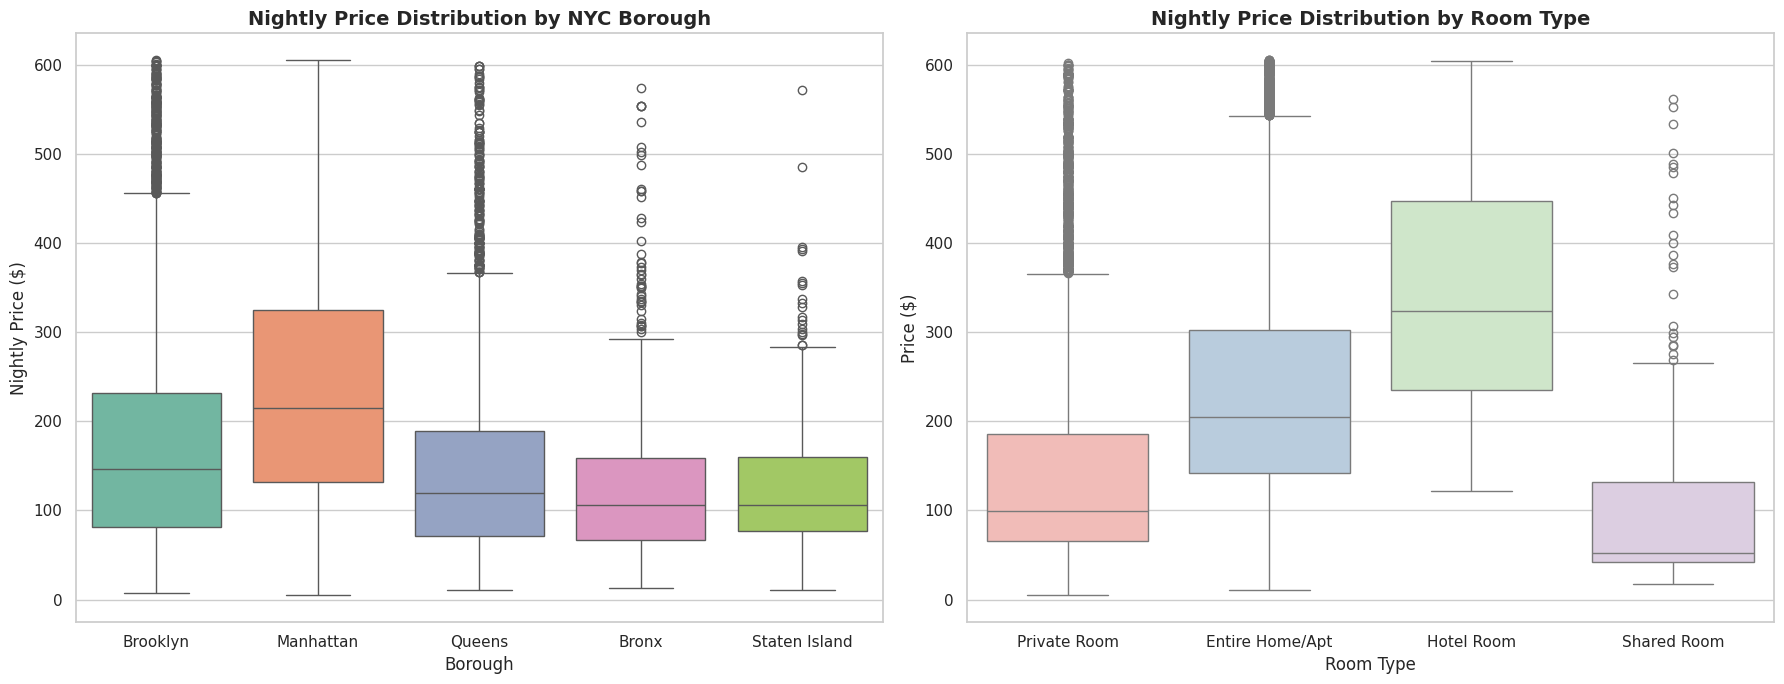

In [30]:
#################Exploratory Data Analysis (EDA)####################
#Step 4.1.3: Visualizing Price Distributions across Categories
#To understand market segments, I use Box Plots to compare how nightly prices vary across Boroughs (Neighbourhood Groups) and Room Types.
# Filter out extreme luxury outliers for visualization clarity
df_viz = df_master[df_master['is_price_outlier'] == False]

# Set up a side-by-side plotting area (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Price Distribution by Borough
sns.boxplot(data=df_viz, x='neighbourhood_group_cleansed', y='price', ax=axes[0], palette='Set2')
axes[0].set_title('Nightly Price Distribution by NYC Borough', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Borough', fontsize=12)
axes[0].set_ylabel('Nightly Price ($)', fontsize=12)

# Plot 2: Price Distribution by Room Type
sns.boxplot(data=df_viz, x='room_type', y='price', ax=axes[1], palette='Pastel1')
axes[1].set_title('Nightly Price Distribution by Room Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Room Type', fontsize=12)
axes[1].set_ylabel('Price ($)', fontsize=12)

plt.tight_layout()
plt.show()

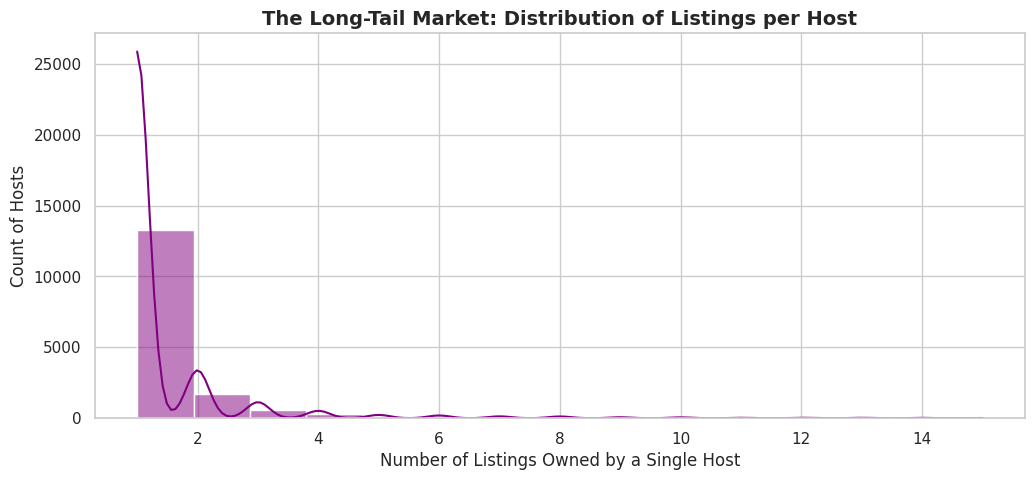


--- 💼 Host Portfolio Breakdown Trends ---
1: Casual (Single Listing): 13276 hosts (80.59%)
2: Multi-Host (2-5 Listings): 2711 hosts (16.46%)
3: Institutional (6+ Listings): 487 hosts (2.96%)


In [31]:
#################Exploratory Data Analysis (EDA)####################
#Step 4.1.4: Analyzing Hosting Portfolios (Power Law Dynamics)
#count how many listings each host owns, and plot the distribution to see if institutional property managers dominate NYC.
# 1. Calculate how many properties each unique host operates
host_portfolios = df_master.groupby('host_id').size().reset_index(name='listing_count')

# 2. Group hosts into portfolio operational tiers
def categorize_host(count):
    if count == 1: return '1: Casual (Single Listing)'
    elif 2 <= count <= 5: return '2: Multi-Host (2-5 Listings)'
    else: return '3: Institutional (6+ Listings)'

host_portfolios['host_tier'] = host_portfolios['listing_count'].apply(categorize_host)
tier_counts = host_portfolios['host_tier'].value_counts().sort_index()

# 3. Plot the Long-Tail Distribution curve
plt.figure(figsize=(12, 5))
sns.histplot(data=host_portfolios[host_portfolios['listing_count'] <= 15], x='listing_count', bins=15, kde=True, color='purple')
plt.title('The Long-Tail Market: Distribution of Listings per Host', fontsize=14, fontweight='bold')
plt.xlabel('Number of Listings Owned by a Single Host', fontsize=12)
plt.ylabel('Count of Hosts', fontsize=12)
plt.show()

# 4. Display the structural breakdown percentages
print("\n--- 💼 Host Portfolio Breakdown Trends ---")
for tier, count in tier_counts.items():
    percentage = (count / len(host_portfolios)) * 100
    print(f"{tier}: {count} hosts ({percentage:.2f}%)")

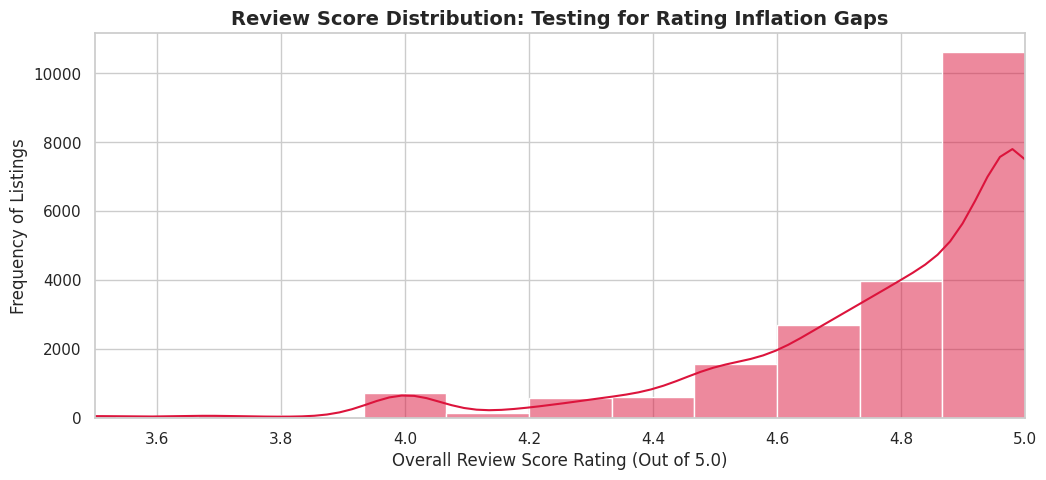

📊 Rating Inflation Metric: 86.82% of rated properties score a 4.5 or higher out of 5.0!


In [32]:
#################Exploratory Data Analysis (EDA)####################
#Step 4.1.5: Review Score Distributions & Rating Inflation
# Filter out properties with no review history (-1 sentinel value)
df_rated = df_master[df_master['review_scores_rating'] > 0]

plt.figure(figsize=(12, 5))
sns.histplot(data=df_rated, x='review_scores_rating', bins=30, kde=True, color='crimson')
plt.title('Review Score Distribution: Testing for Rating Inflation Gaps', fontsize=14, fontweight='bold')
plt.xlabel('Overall Review Score Rating (Out of 5.0)', fontsize=12)
plt.ylabel('Frequency of Listings', fontsize=12)
plt.xlim(3.5, 5.0) # Zooming into the core cluster zone
plt.show()

# Calculate the exact percentage of reviews that are 4.5 or higher
high_ratings = len(df_rated[df_rated['review_scores_rating'] >= 4.5])
inflation_rate = (high_ratings / len(df_rated)) * 100
print(f"📊 Rating Inflation Metric: {inflation_rate:.2f}% of rated properties score a 4.5 or higher out of 5.0!")

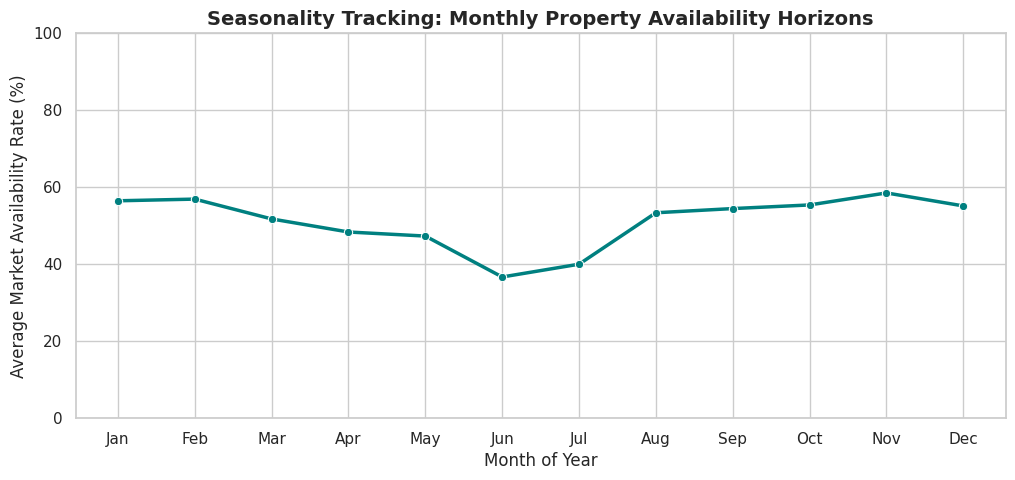

In [33]:
#################Exploratory Data Analysis (EDA)####################
#Step 4.1.6: Seasonal Availability and Booking Fluctuations
# 1. Reload the cleaned daily calendar dataset
df_calendar_raw = pd.read_csv('Expernetic_Assignment/processed_data/calendar_cleaned.csv.gz', compression='gzip')
df_calendar_raw['date'] = pd.to_datetime(df_calendar_raw['date'])

# 2. Extract Month name and calculate booking availability flags
df_calendar_raw['month_name'] = df_calendar_raw['date'].dt.strftime('%b')
df_calendar_raw['month_num'] = df_calendar_raw['date'].dt.month
df_calendar_raw['is_available_binary'] = df_calendar_raw['available'].apply(lambda x: 1 if x == 't' else 0)

# 3. Compute monthly average availability rates
monthly_trends = df_calendar_raw.groupby(['month_num', 'month_name'])['is_available_binary'].mean().reset_index()
monthly_trends['availability_percentage'] = monthly_trends['is_available_binary'] * 100

# 4. Plot the Seasonal Horizon
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_trends, x='month_name', y='availability_percentage', marker='o', color='teal', linewidth=2.5)
plt.title('Seasonality Tracking: Monthly Property Availability Horizons', fontsize=14, fontweight='bold')
plt.xlabel('Month of Year', fontsize=12)
plt.ylabel('Average Market Availability Rate (%)', fontsize=12)
plt.ylim(0, 100)
plt.show()

In [34]:
#################Exploratory Data Analysis (EDA)####################
#Task 4.2: Geographic & Spatial Analysis!
#Step 4.2.1: Mapping Listing Density via Interactive Heatmaps
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap

# 1. Reload the master dataset and isolate non-outliers for clean visualization scales
df_master = pd.read_csv('Expernetic_Assignment/processed_data/nyc_master_enriched.csv.gz', compression='gzip', low_memory=False)
df_viz = df_master[df_master['is_price_outlier'] == False].copy()

print("--- Step 1: Generating Interactive Listing Density Heatmap ---")

# 2. Set the center coordinates for New York City (Midtown Manhattan area)
nyc_center = [40.7580, -73.9855]
density_map = folium.Map(location=nyc_center, zoom_start=11, tiles='CartoDB positron')

# 3. Extract latitude and longitude pairs for the heatmap engine
heat_data = df_viz[['latitude', 'longitude']].dropna().values.tolist()

# 4. Add the HeatMap layer to our map canvas
HeatMap(heat_data, radius=8, max_zoom=13, blur=5).add_to(density_map)

# Save map as an individual HTML file
density_map.save('Expernetic_Assignment/processed_data/nyc_density_heatmap.html')
print("💾 Heatmap successfully saved to your workspace as 'nyc_density_heatmap.html'!")

# Render the interactive map directly inside your notebook window
density_map

--- Step 1: Generating Interactive Listing Density Heatmap ---
💾 Heatmap successfully saved to your workspace as 'nyc_density_heatmap.html'!


--- Step 2: Computing Distance-to-Center Pricing Gradients ---


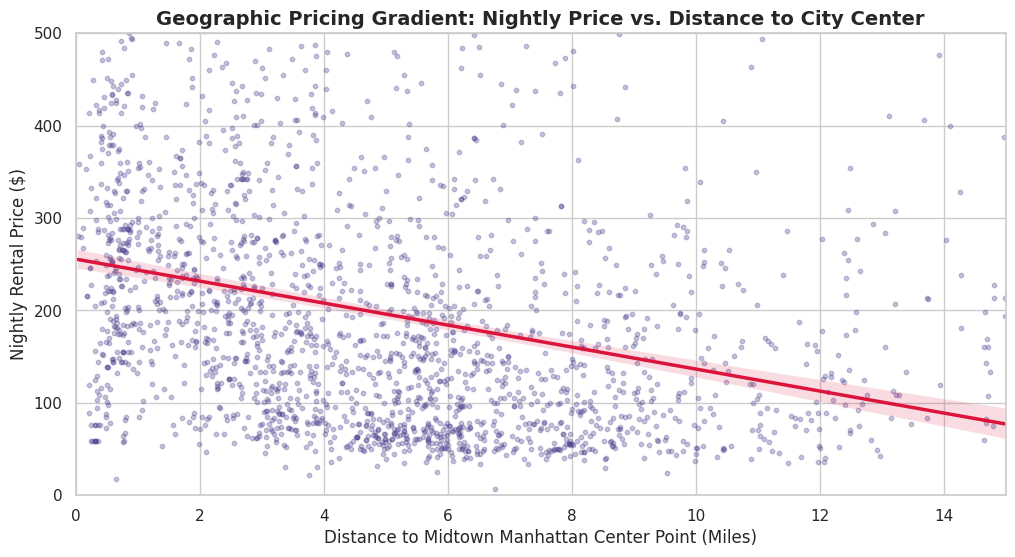

📊 Statistical Note: Pearson Correlation between Price and Proximity to Center is: -0.315


In [35]:
#################Exploratory Data Analysis (EDA)####################
#Step 4.2.2: Identifying Geographic Pricing Gradients
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Step 2: Computing Distance-to-Center Pricing Gradients ---")

# 1. Vectorized Haversine Distance Function to calculate miles from Times Square
def calculate_haversine_distance(lat1, lon1, lat2, lon2):
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine structural core
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))

    miles = 3956 * c # 3,956 miles is the average radius of Planet Earth
    return miles

# 2. Coordinates of NYC Center (Times Square / Midtown Manhattan)
center_lat, center_lon = 40.7580, -73.9855

# 3. Run calculation across all rows instantly using fast vectorized numpy arrays
df_viz['distance_to_center_miles'] = calculate_haversine_distance(
    df_viz['latitude'], df_viz['longitude'], center_lat, center_lon
)

# 4. Generate a trend scatter plot with an overlayed linear regression trendline
plt.figure(figsize=(12, 6))
sns.regplot(
    data=df_viz.sample(n=3000, random_state=42), # Sample 3,000 nodes for visual cleanliness
    x='distance_to_center_miles',
    y='price',
    scatter_kws={'alpha': 0.3, 'color': 'darkslateblue', 's': 10},
    line_kws={'color': 'crimson', 'linewidth': 2.5}
)

plt.title('Geographic Pricing Gradient: Nightly Price vs. Distance to City Center', fontsize=14, fontweight='bold')
plt.xlabel('Distance to Midtown Manhattan Center Point (Miles)', fontsize=12)
plt.ylabel('Nightly Rental Price ($)', fontsize=12)
plt.xlim(0, 15)
plt.ylim(0, 500)
plt.show()

# Print the mathematical correlation coefficient link
correlation = df_viz['distance_to_center_miles'].corr(df_viz['price'])
print(f"📊 Statistical Note: Pearson Correlation between Price and Proximity to Center is: {correlation:.3f}")

--- Step 3: Aggregating Quality Ratings Across Spatial Neighborhoods ---


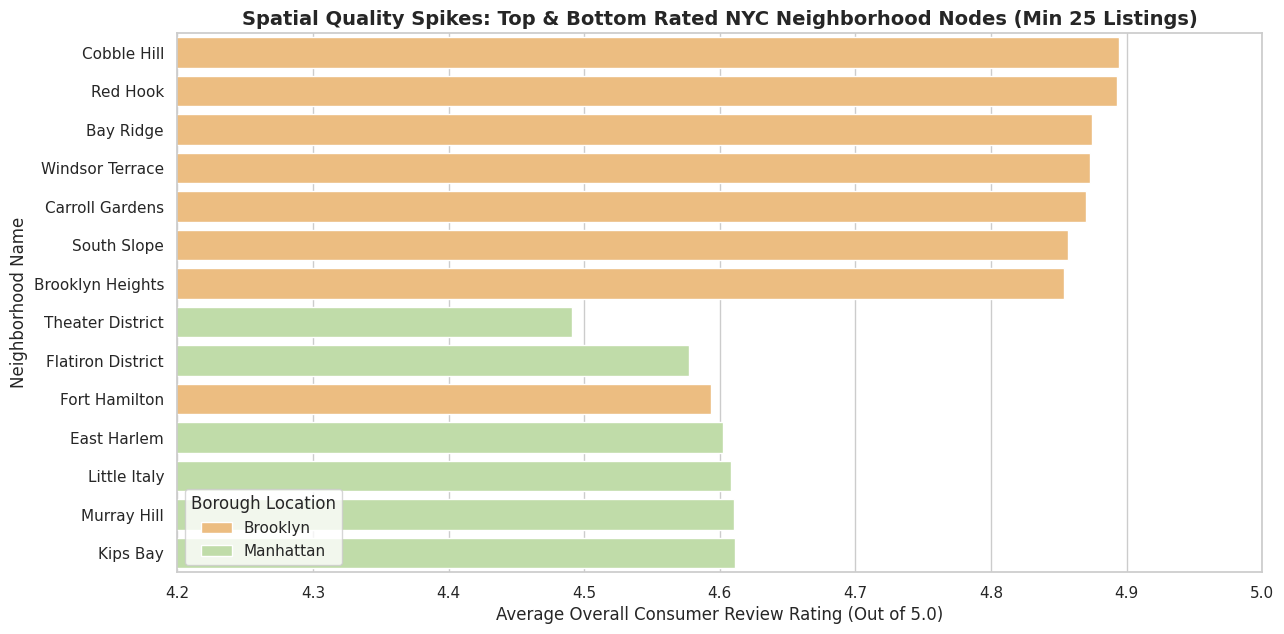

In [36]:
#################Exploratory Data Analysis (EDA)####################
#Step 4.2.3: Spatial Review Score Analysis (Happy vs. Unhappy Neighborhoods)
print("--- Step 3: Aggregating Quality Ratings Across Spatial Neighborhoods ---")

# 1. Filter out unrated listings (-1) and group by neighborhood nodes
df_rated_neighborhoods = df_master[df_master['review_scores_rating'] > 0].groupby(
    ['neighbourhood_cleansed', 'neighbourhood_group_cleansed']
).agg(
    total_listings=('id', 'count'),
    avg_rating=('review_scores_rating', 'mean')
).reset_index()

# 2. Isolate neighborhoods with at least 25 active listings to guarantee fair statistical sample sizing
df_filtered_neighborhoods = df_rated_neighborhoods[df_rated_neighborhoods['total_listings'] >= 25]

# 3. Pull Top 7 and Bottom 7 neighborhoods based on average rating score performance
top_neighborhoods = df_filtered_neighborhoods.sort_values(by='avg_rating', ascending=False).head(7)
bottom_neighborhoods = df_filtered_neighborhoods.sort_values(by='avg_rating', ascending=True).head(7)
combined_ranking = pd.concat([top_neighborhoods, bottom_neighborhoods])

# 4. Draw a clear horizontal comparison bar chart
plt.figure(figsize=(14, 7))
sns.barplot(
    data=combined_ranking,
    x='avg_rating',
    y='neighbourhood_cleansed',
    hue='neighbourhood_group_cleansed',
    palette='Spectral',
    dodge=False
)

plt.title('Spatial Quality Spikes: Top & Bottom Rated NYC Neighborhood Nodes (Min 25 Listings)', fontsize=14, fontweight='bold')
plt.xlabel('Average Overall Consumer Review Rating (Out of 5.0)', fontsize=12)
plt.ylabel('Neighborhood Name', fontsize=12)
plt.xlim(4.2, 5.0) # Zooming into the evaluation variance zone
plt.legend(title='Borough Location', loc='lower left')
plt.show()

--- Step 4: Plotting Asset Type Layouts Across the City Footprint ---


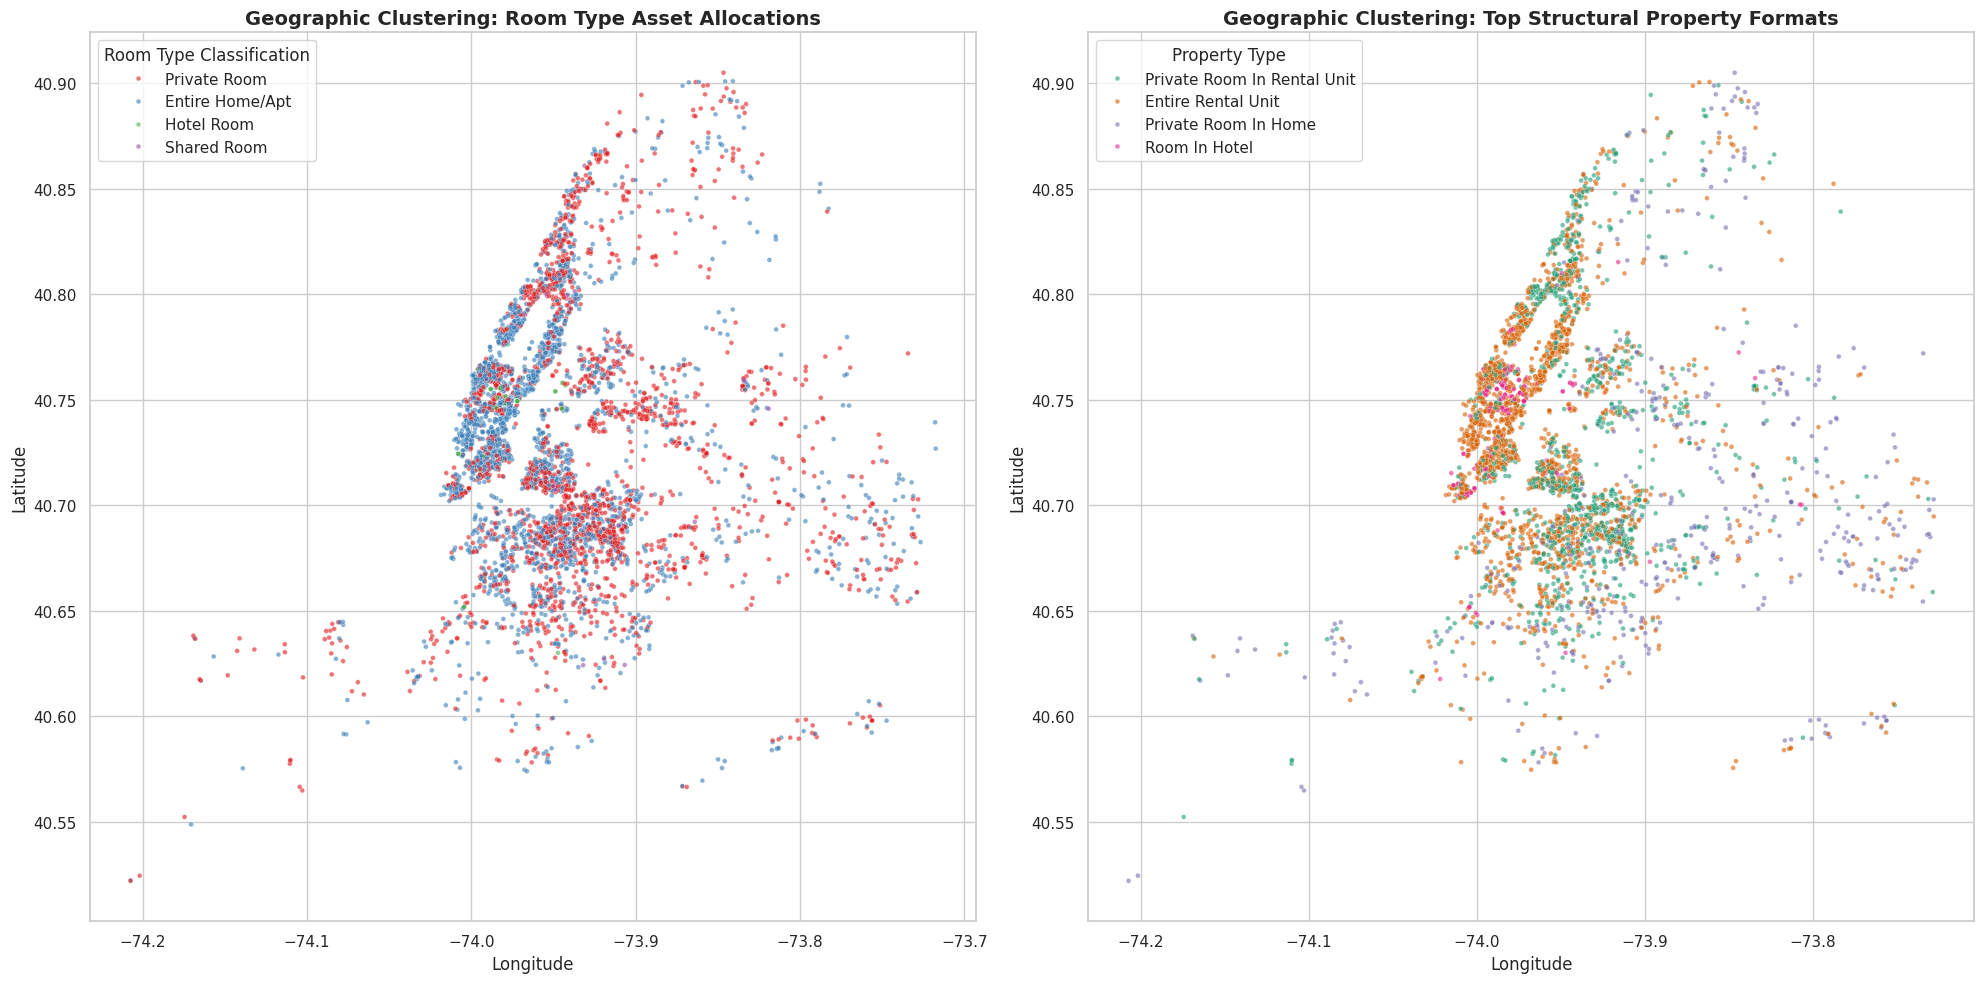

In [37]:
#################Exploratory Data Analysis (EDA)####################
#Step 4.2.4: Geographic Clustering of Property and Room Types
print("--- Step 4: Plotting Asset Type Layouts Across the City Footprint ---")

# Set up a side-by-side comparative canvas layout
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Sample down data rows slightly for plotting optimization speeds
df_map_sample = df_viz.sample(n=5000, random_state=101)

# Map 1: Geographic Distribution of Room Types
sns.scatterplot(
    data=df_map_sample,
    x='longitude',
    y='latitude',
    hue='room_type',
    palette='Set1',
    s=12,
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Geographic Clustering: Room Type Asset Allocations', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Longitude', fontsize=12)
axes[0].set_ylabel('Latitude', fontsize=12)
axes[0].legend(title='Room Type Classification')

# Map 2: Geographic Distribution of Top 4 Property Types
top_4_properties = df_viz['property_type'].value_counts().head(4).index
df_property_sample = df_map_sample[df_map_sample['property_type'].isin(top_4_properties)]

sns.scatterplot(
    data=df_property_sample,
    x='longitude',
    y='latitude',
    hue='property_type',
    palette='Dark2',
    s=12,
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title('Geographic Clustering: Top Structural Property Formats', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitude', fontsize=12)
axes[1].set_ylabel('Latitude', fontsize=12)
axes[1].legend(title='Property Type')

plt.tight_layout()
plt.show()

--- Step 1: Cleaning Calendar Prices and Tracking Monthly Evolution ---


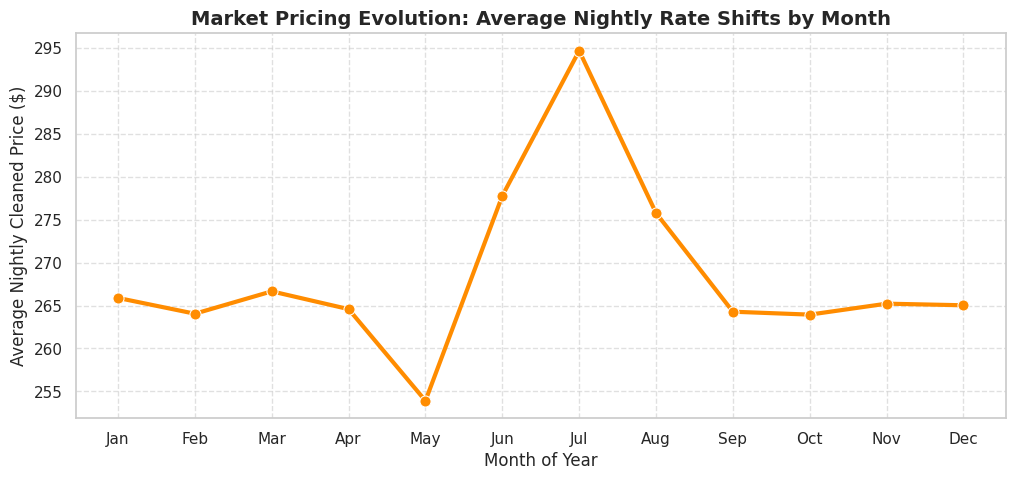

,month_name,price_clean
0,Jan,265.88
1,Feb,264.04
2,Mar,266.65
3,Apr,264.58
4,May,253.92
5,Jun,277.76
6,Jul,294.65
7,Aug,275.76
8,Sep,264.28
9,Oct,263.94


In [38]:
#################Exploratory Data Analysis (EDA)####################
#Task 4.3: Temporal & Seasonal Trends
#Pricing Evolution Across the Calendar Year
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Step 1: Cleaning Calendar Prices and Tracking Monthly Evolution ---")

# 1. Ensure the date column is in the correct datetime format
df_calendar['date'] = pd.to_datetime(df_calendar['date'])

# 2. Extract month index and month name directly within this cell to prevent KeyErrors
df_calendar['month_index'] = df_calendar['date'].dt.month
df_calendar['month_name'] = df_calendar['date'].dt.strftime('%b')

# 3. Clean the price column in the calendar dataframe (removing $, commas, and spaces)
df_calendar['price_clean'] = pd.to_numeric(
    df_calendar['price'].astype(str).str.replace(r'[\$,]', '', regex=True),
    errors='coerce'
).fillna(0)

# 4. Filter for rows where properties are actively open for booking
df_available = df_calendar[df_calendar['available'] == 't']

# 5. Compute the average price for each month (and sort so it goes from Jan to Dec)
monthly_prices = df_available.groupby(['month_index', 'month_name'])['price_clean'].mean().reset_index()
monthly_prices = monthly_prices.sort_values('month_index')

# 6. Plot the price timeline across a 12-month horizon
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_prices,
    x='month_name',
    y='price_clean',
    marker='o',
    color='darkorange',
    linewidth=3,
    markersize=8
)

plt.title('Market Pricing Evolution: Average Nightly Rate Shifts by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month of Year', fontsize=12)
plt.ylabel('Average Nightly Cleaned Price ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Display the exact average numbers for your report text
display(monthly_prices[['month_name', 'price_clean']].round(2))

--- Step 2: Analyzing Long-Term Platform Review Waves ---


/tmp/ipykernel_3000/3657004174.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_reviews, x='Year', y='Active_Review_Count', palette='Blues_d')


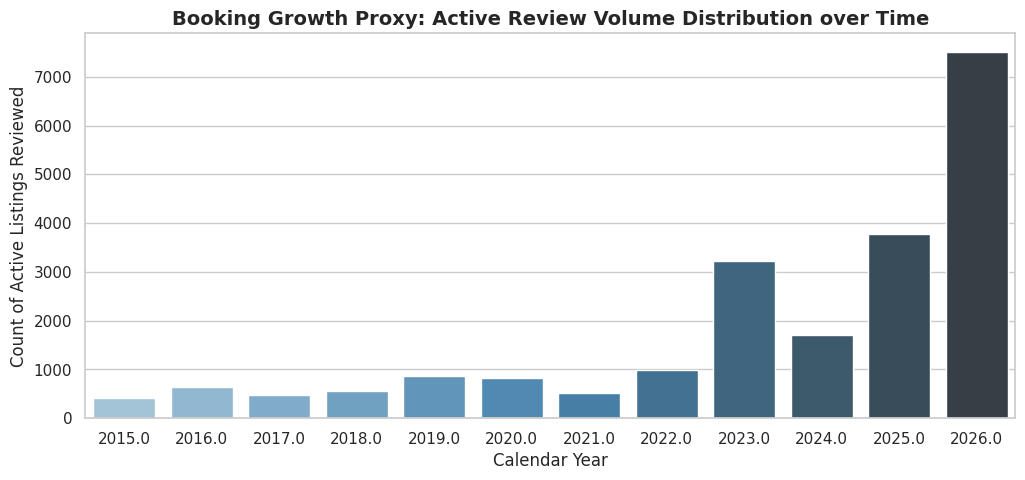

,Year,Active_Review_Count
0,2015.0,411
1,2016.0,631
2,2017.0,479
3,2018.0,553
4,2019.0,875
5,2020.0,826
6,2021.0,526
7,2022.0,993
8,2023.0,3233
9,2024.0,1703


In [39]:
#################Exploratory Data Analysis (EDA)####################

#Historical Review Volume Trends (Booking Proxy)
print("--- Step 2: Analyzing Long-Term Platform Review Waves ---")

# 1. Ensure the review date feature is parsed into a datetime type
df_master['last_review_dt'] = pd.to_datetime(df_master['last_review'], errors='coerce')

# 2. Extract the operational year from the date
df_master['review_year'] = df_master['last_review_dt'].dt.year

# 3. Count how many listings had their most recent booking/review in each year
yearly_reviews = df_master[df_master['review_year'] >= 2015]['review_year'].value_counts().sort_index().reset_index()
yearly_reviews.columns = ['Year', 'Active_Review_Count']

# 4. Generate a bar chart showing historical volume
plt.figure(figsize=(12, 5))
sns.barplot(data=yearly_reviews, x='Year', y='Active_Review_Count', palette='Blues_d')
plt.title('Booking Growth Proxy: Active Review Volume Distribution over Time', fontsize=14, fontweight='bold')
plt.xlabel('Calendar Year', fontsize=12)
plt.ylabel('Count of Active Listings Reviewed', fontsize=12)
plt.show()

display(yearly_reviews)

--- Step 4: Tracking Seasonal Variations in Minimum Night Stays ---


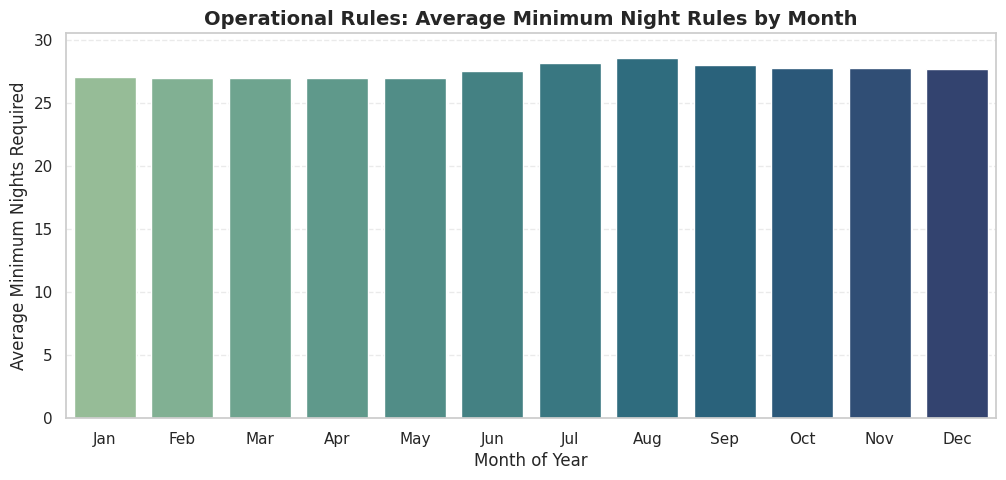

,month_name,minimum_nights
0,Jan,27.04
1,Feb,26.94
2,Mar,26.94
3,Apr,26.95
4,May,26.97
5,Jun,27.51
6,Jul,28.17
7,Aug,28.53
8,Sep,28.02
9,Oct,27.80


In [40]:
#################Exploratory Data Analysis (EDA)####################

#Seasonal Shifts in Minimum Night Policies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Step 4: Tracking Seasonal Variations in Minimum Night Stays ---")

# 1. Safeguard: Ensure the calendar date features are loaded and sorted properly
df_calendar['date'] = pd.to_datetime(df_calendar['date'])
df_calendar['month_index'] = df_calendar['date'].dt.month
df_calendar['month_name'] = df_calendar['date'].dt.strftime('%b')

# 2. Group by month and calculate the average minimum nights requirement
seasonal_min_nights = df_calendar.groupby(['month_index', 'month_name'])['minimum_nights'].mean().reset_index()
seasonal_min_nights = seasonal_min_nights.sort_values('month_index')

# 3. Plot the minimum night requirements across the year
plt.figure(figsize=(12, 5))

# FIXED: Changed 'emerald' to the valid 'crest' palette, and set hue='month_name' to stop the warning
sns.barplot(
    data=seasonal_min_nights,
    x='month_name',
    y='minimum_nights',
    hue='month_name',
    palette='crest',
    legend=False
)

plt.title('Operational Rules: Average Minimum Night Rules by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month of Year', fontsize=12)
plt.ylabel('Average Minimum Nights Required', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4, axis='y')

# Dynamically pad the top of the chart safely
plt.ylim(0, seasonal_min_nights['minimum_nights'].max() + 2)
plt.show()

# Display the final summary dataframe
display(seasonal_min_nights[['month_name', 'minimum_nights']].round(2))